In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

seed= 42

In [24]:
def preprocess_data(data):
    df= data.copy()

    df.drop(columns=['SampleID'])
    df['volume']= df['x']* df['y'] * df['z']

    return df

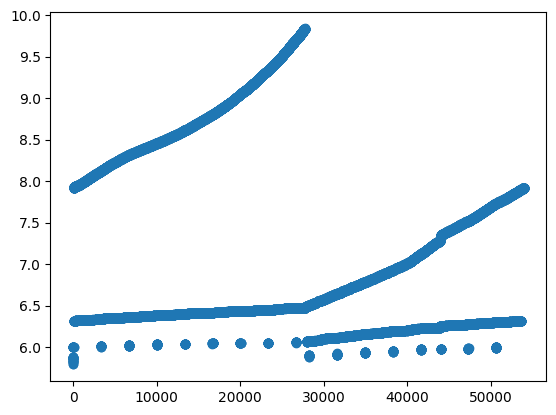

In [25]:
train_df= pd.read_csv("train.csv")
test_df= pd.read_csv("test.csv")

X_train= preprocess_data(train_df.drop(columns=['price']))
y_train= np.log1p(train_df['price'])

X_test= preprocess_data(test_df)
plt.scatter(train_df['SampleID'], y_train)
plt.show()

In [26]:
# Subtask 1

answer1= pd.DataFrame({
    'subtaskID': 1,
    'datapointID': test_df['SampleID'],
    'answer': test_df['carat'].apply(lambda x: 'Light' if x < 0.5 else ('Medium' if x < 1.5 else 'Heavy'))
})

answer1.head()

,subtaskID,datapointID,answer
0,1,1389,Light
1,1,50053,Medium
2,1,41646,Light
3,1,42378,Light
4,1,17245,Heavy


In [27]:
# Subtask 2

answer2= pd.DataFrame({
    'subtaskID': 2,
    'datapointID': test_df['SampleID'],
    'answer': test_df['depth'] / test_df['table']
})

answer2.head()

,subtaskID,datapointID,answer
0,2,1389,1.108929
1,2,50053,1.052632
2,2,41646,1.129091
3,2,42378,1.066667
4,2,17245,1.132727


In [28]:
# Subtask 3

answer3= pd.DataFrame({
    'subtaskID': 3,
    'datapointID': test_df['SampleID'],
    'answer': X_test['volume']
})

answer3.head()

,subtaskID,datapointID,answer
0,3,1389,39.223600
1,3,50053,96.120448
2,3,41646,66.559080
3,3,42378,71.695224
4,3,17245,252.779208


In [29]:
# Subtask 4
from catboost import CatBoostRegressor

cat_cols= X_train.select_dtypes(include=['object', 'str']).columns.to_list()

model= CatBoostRegressor(
    iterations=3000,
    learning_rate=0.03,
    depth=6,
    cat_features=cat_cols,
    early_stopping_rounds=200,
    random_state= seed
)

model.fit(X_train, y_train, verbose= 200)

0:	learn: 0.9870472	total: 63.3ms	remaining: 3m 9s
200:	learn: 0.0726562	total: 1.88s	remaining: 26.4s
400:	learn: 0.0550478	total: 3.58s	remaining: 23.3s
600:	learn: 0.0479184	total: 5.13s	remaining: 20.5s
800:	learn: 0.0424682	total: 6.79s	remaining: 18.7s
1000:	learn: 0.0387611	total: 8.44s	remaining: 16.9s
1200:	learn: 0.0359530	total: 10.1s	remaining: 15.1s
1400:	learn: 0.0337647	total: 11.7s	remaining: 13.4s
1600:	learn: 0.0317790	total: 13.4s	remaining: 11.7s
1800:	learn: 0.0302167	total: 15.1s	remaining: 10.1s
2000:	learn: 0.0288690	total: 16.7s	remaining: 8.39s
2200:	learn: 0.0276622	total: 18.4s	remaining: 6.7s
2400:	learn: 0.0266467	total: 20.1s	remaining: 5.03s
2600:	learn: 0.0257346	total: 21.7s	remaining: 3.35s
2800:	learn: 0.0248753	total: 23.4s	remaining: 1.67s
2999:	learn: 0.0241093	total: 25.1s	remaining: 0us


CatBoostRegressor(cat_features=['cut', 'color', 'clarity'], depth=6, early_stopping_rounds=200, iterations=3000, learning_rate=0.03, loss_function='RMSE', random_state=42)

In [30]:
predictions= np.expm1(model.predict(X_test))

answer4= pd.DataFrame({
    'subtaskID': 4,
    'datapointID': test_df['SampleID'],
    'answer': predictions
})

answer4.head()

,subtaskID,datapointID,answer
0,4,1389,547.213867
1,4,50053,2207.568009
2,4,41646,1244.686872
3,4,42378,1324.692857
4,4,17245,7171.981164


In [31]:
answer= pd.concat([answer1, answer2, answer3, answer4])

answer.to_csv("submission.csv", index= False)